# 01 - Exploratory Data Analysis
## Give Me Some Credit - Loan Default Prediction
The goal of this notebook is to understand the data before touching a model. Specifically: 
* What does the target distribution look like (how imbalanced is it)?
* Where is data missing, and does missingness look random?
* What do individual feature distribution look like? Are there any obvious outliers or data entry errors?
* Which features look most related to the target?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1.Load data
`cs-training.csv` has an unnamed index column from the original Kaggle export, so I will drop it.

In [2]:
df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Basic structure
What are the column names, dtypes, and a first pass on missingness

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing/len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


The two columns with missing values are monthly income (19.8%) and number of dependents (2.6%).

## 3. Target distribution
`SeriousDlqin2yrs` is the target variable: 1 = experience serious delinquency within 2 years

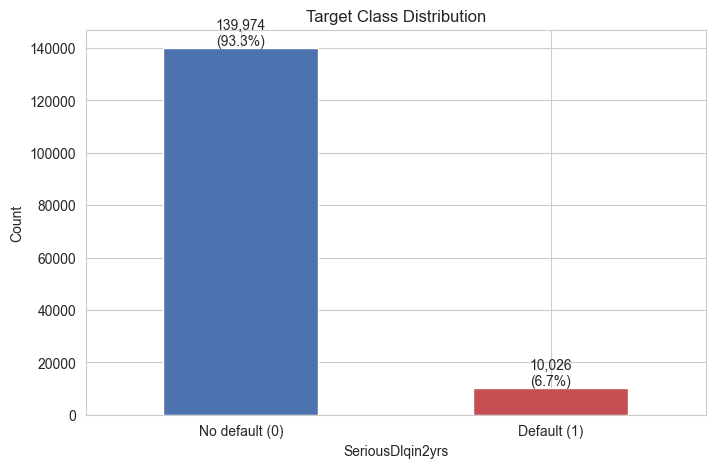

In [5]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
fig, ax = plt.subplots()
target_counts.plot(kind='bar', ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution')
for i, (count, pct) in enumerate(zip(target_counts, target_pct)):
    ax.text(i, count, f"{count:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.show()

Only around 6.7% of borrowers are in serious delinquency within two years, this huge class imbalance wil affect models down the road.

## 4. Numeric Feature distributions
Here I will plot each feature's distribution. I'm watching for:
* implausible values (e.g. `age` = 0, or utilization ratios > 10 which shouldn't be possible)
* extreme outliers drivers by a handful of rows
* skew that might warrant a transform later

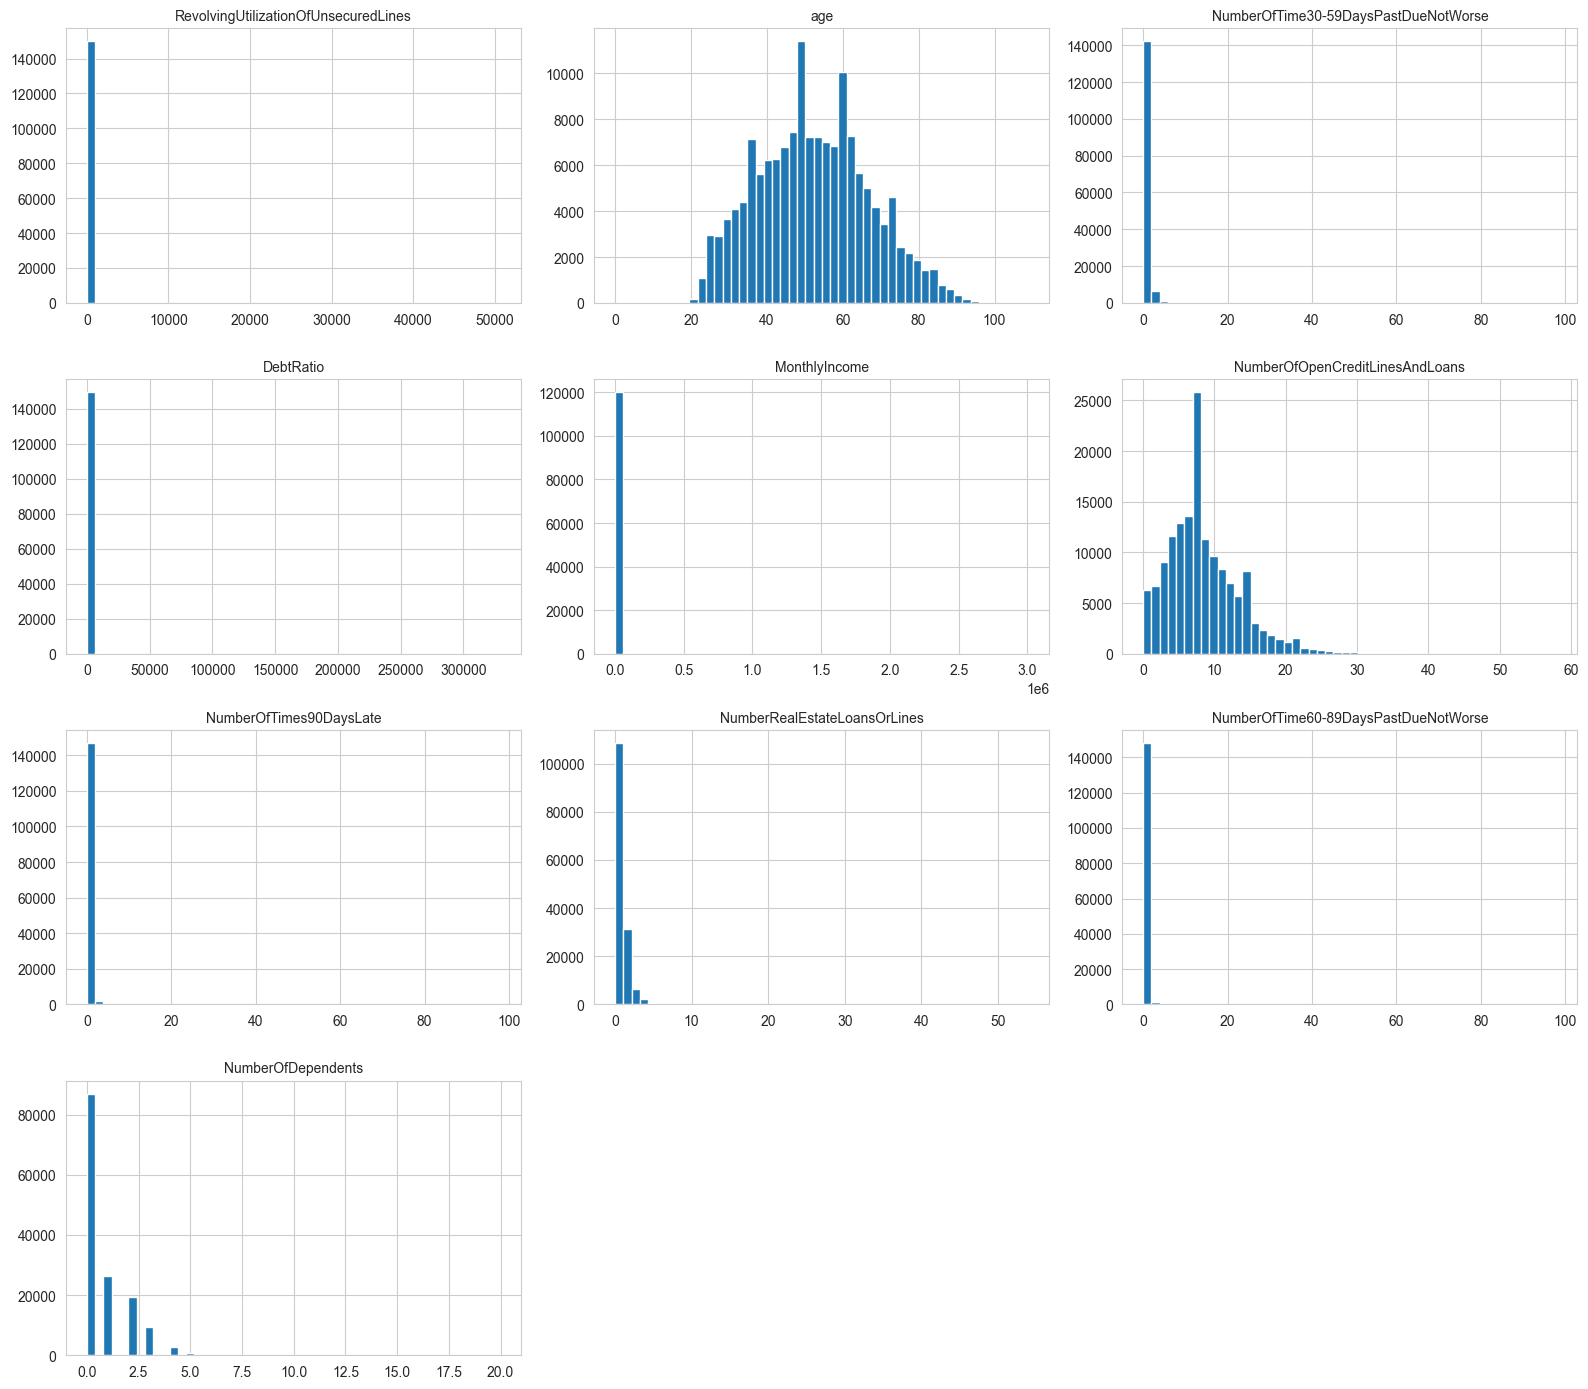

In [7]:
numeric_cols = [c for c in df.columns if c != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].hist(bins=50, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [8]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0
NumberOfDependents,146076.0,0.757222,1.115086,0.0,0.000000,0.000000,1.000000,20.0


Some things I'm noticing:
* there's a minimum `age` that has a 0 value and a maximum age of 109 (maybe a data entry error or not a real applicant)
* `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` have some extreme outliers (some are in the thousands)
* `NumberOfTimes30-59PastDueNotWorse`, `NumberOfTimes60-89DaysPastDueNotWorse` and `NumberofTimes90DaysLate` all have maximum values of 98.0 which are likely not real counts

## 5. Outlier check via boxplots
Here I will check outliers using boxplots because boxplots make extreme values easier to spot than histograms for skewed features

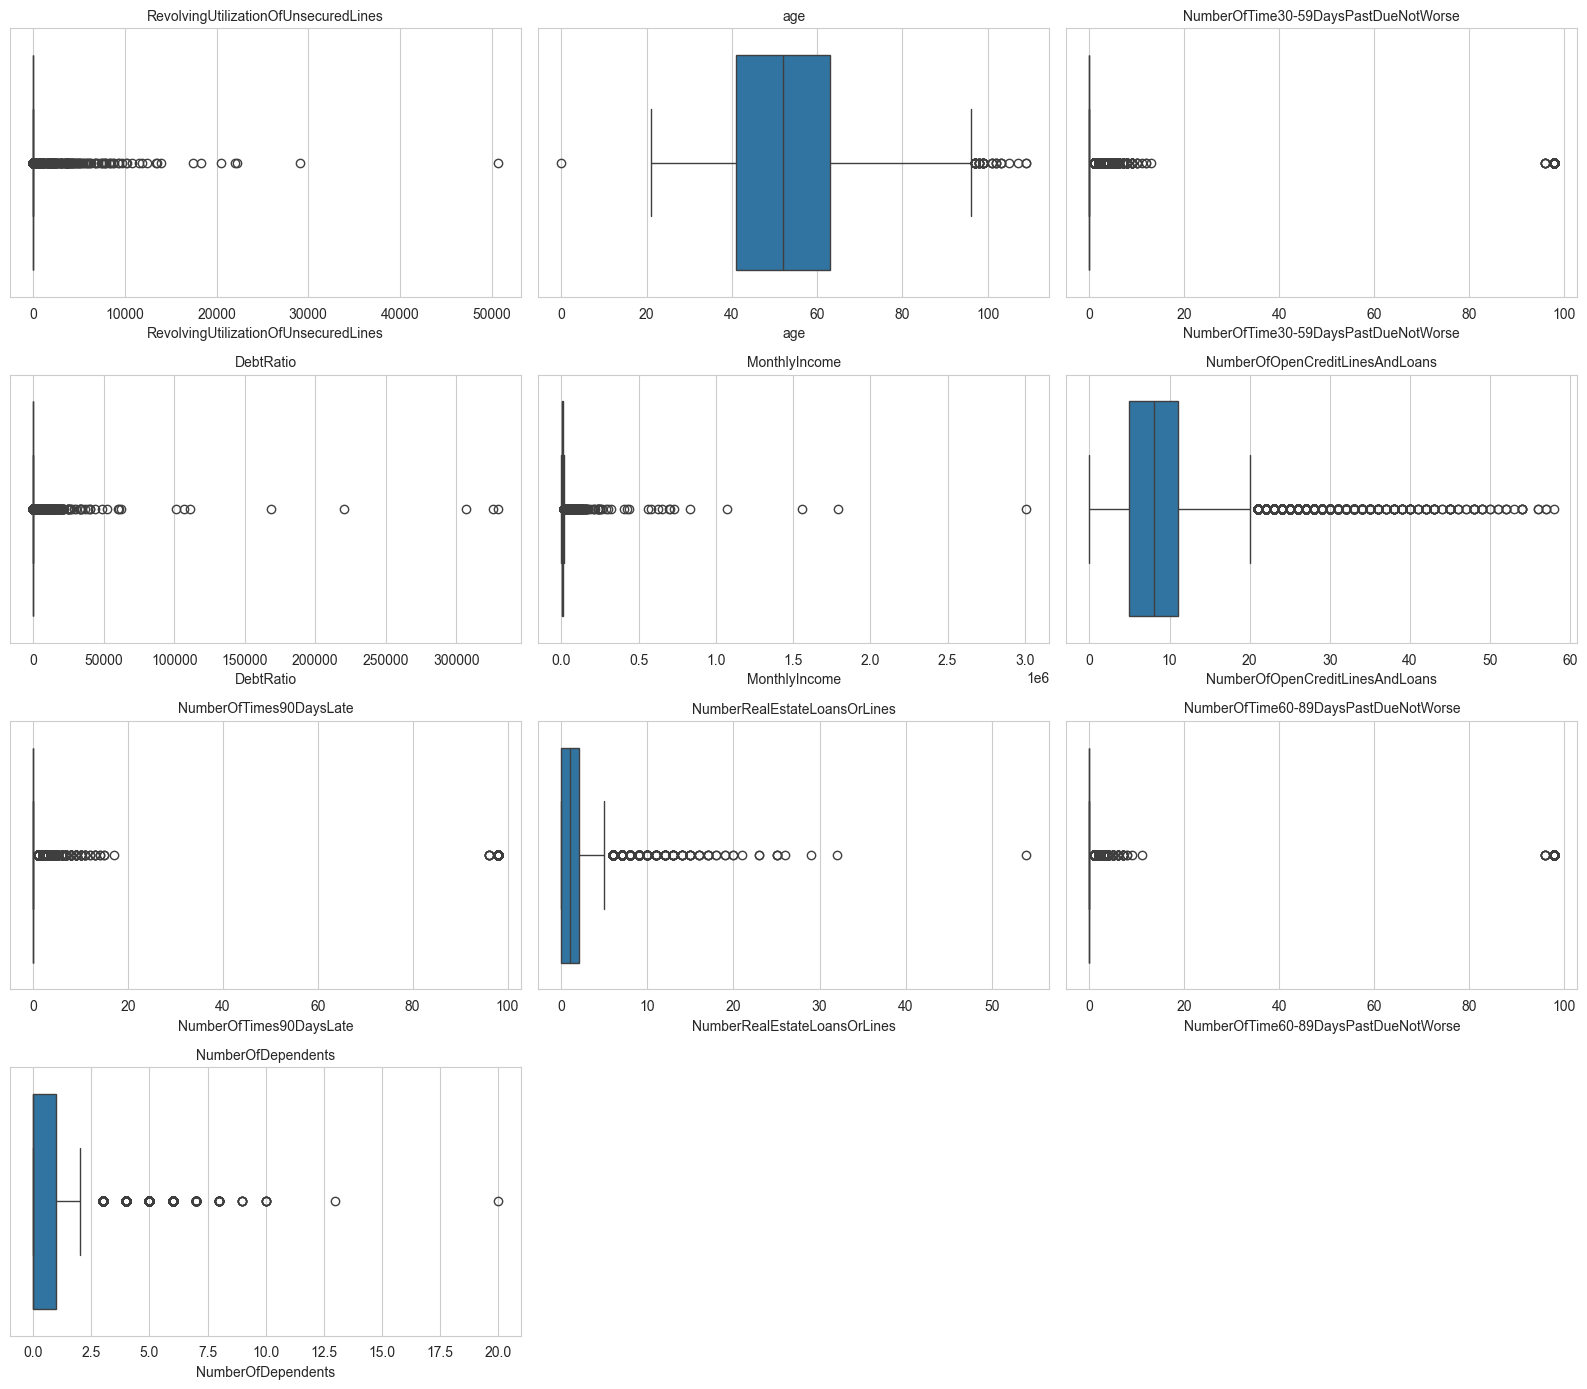

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## 6. Features vs. target relationships
For each numeric feature, compare its distribution between defaulters and non-defaults. This gives an early, cheap signal of which features might matter most; this is useful to sanity check against feature importance/SHAP later.

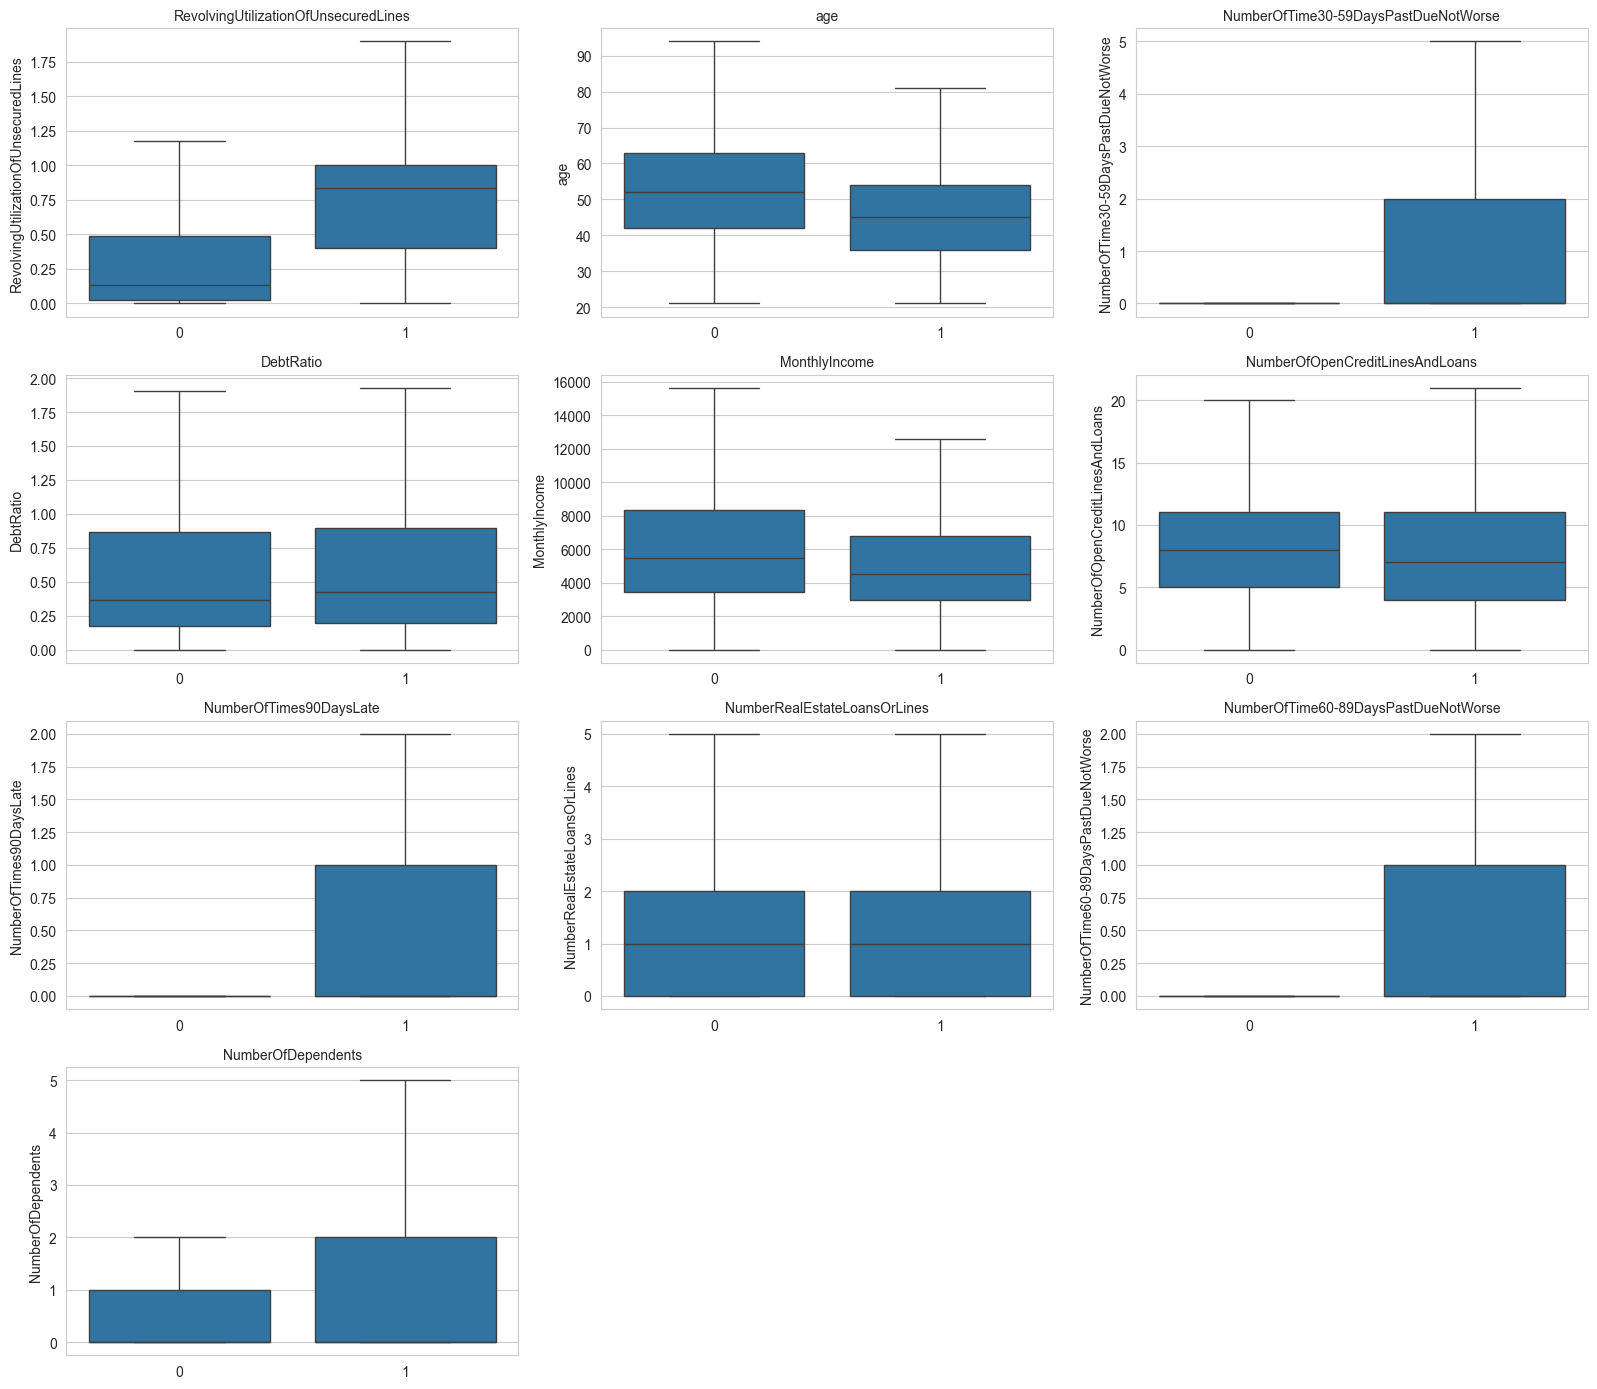

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="SeriousDlqin2yrs", y=col, data=df, ax=axes[i], showfliers=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The columns that seem to have the cleanest separation between the two classes are the "times late" columns and the `RevolvingUtilizationOfUnsecuredLines`. It's surprising that `MonthlyIncome` and `age` don't have cleaner separations between the two classes as expected.

## 7. Correlation matrix
In this section, I am checking for multicollinearity among the three "times late" columns, which are likely correlated with each other

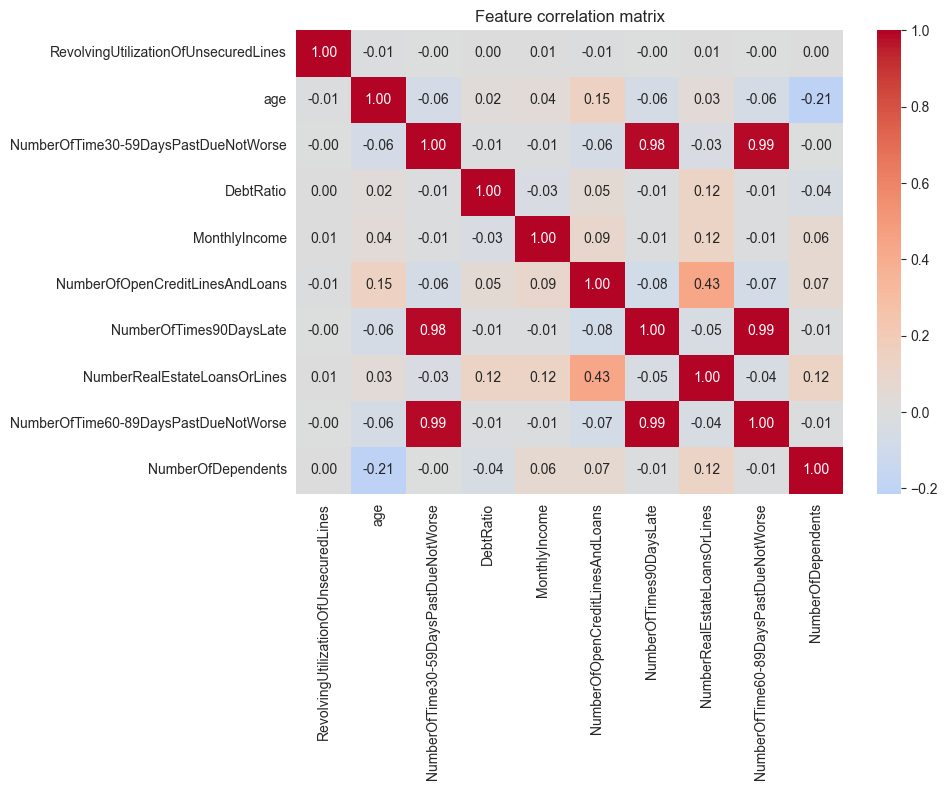

In [13]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

As expected, the "times late" columns are all highly positively correlated to each other between 0.98 and 0.99. This is important for any baseline models that may not handle multicollinearity, so these columns may need to be dropped.

## 8. Summary of findings
* there is a severe class imbalance between the groups for the target variable
* there is missing data in the `MonthlyIncome` and `NumberofDependents` (19.8% vs. 2.6%)
* The "times late" columns have some extreme outliers
* `RevolvingUtilizationOfUnsecuredLines` may have some strong predictive potential in future models